# Prediction of stop 1000 GeV in DM channel 3

In [2]:
# To import seaborn, we need to pip install it first. 
# Run this cell and restart the kernel before continuing
# (circle with arrow symbol on the top bar)
!pip install --no-index seaborn

Ignoring pip: markers 'python_version < "3"' don't match your environment
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/avx512, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/avx2, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic


In [1]:
from seaborn import heatmap

In [2]:
# In case of problems with importing libraries in this cell
# Go to "Softwares" (blue cube symbol on the left)
# Load scipy-stack/2023a StdEnv/2020 gcc/9.3.0 root/6.26.06
# then re-select the Python 3.9 kernel on the top right 
import numpy as np
from pathlib import Path
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
import re

from tabulate import tabulate

import pandas as pd
from copy import deepcopy

import ROOT # needs StdEnv/2020 gcc/9.3.0 root/6.26.06

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable

remove_NaN = lambda row : row[np.isfinite(row)]

# from calculatez import calc_z, calc_z_dist, calc_mu_for_wanted_z, calc_z_bump_scan, neg_log_likelihood

Welcome to JupyROOT 6.26/06


## Load functions

In [3]:
class AttrDict(dict):
    def __init__(self, *args, **kwargs):
        super(AttrDict, self).__init__(*args, **kwargs)
        self.__dict__ = self

In [4]:
def get_readable_name(hname=None, selection=None, distribution=None):

    if 'hCat' not in hname:
        return hname

    # Objects definition
    objects = ['Wh', 'T', 'HM', 'Z', 'g', 'e', 'm', 'bExc', 'ex']
    extra = ['200met', 'incl']
    # Observable
    observables = {'mass' : 'm', 'massT' : 'mT', 'massMET' : 'mMET'}

    if hname:
        selection, distribution = hname.split('__')

    if hname or selection:

        elements = selection.split('_')[1:]
        non_zero_elements = [e for e in elements if e[0].isalpha() or (e[0].isdigit() and eval(e[0]) != 0)]

        # Identify objects
        present_objects = [e for e in non_zero_elements if e[1:] in objects or e[2:] in objects]
        final_state_objects = ''.join([p.replace('bExc','b').replace('ex','j') for p in present_objects])

        # Identify extra
        present_extra = [e for e in non_zero_elements if e[1:] not in objects and e[2:] not in objects]
        final_state_extra = '+'+'+'.join(present_extra)

        # Combine final state
        final_state = final_state_objects
        if len(present_extra) != 0:
            final_state += final_state_extra

    if hname or distribution:
        # Identify distribution observable
        obj = distribution.split('_')[0].replace('.',',')
        obs = distribution.split('_')[1]
        quantity = f'{observables[obs]}({obj})'


    if hname:
        out = final_state, quantity
    elif selection:
        out = final_state
    elif distribution:
        out = quantity
    return ' - '.join(out)

In [5]:
def get_1d_hist(obs, output, 
                mass_binning=None,
                zpred=None, bpred=None,
                title=None, 
                log=True,
                show=True):

    bin_centers = (mass_binning[:-1]+mass_binning[1:])/2 if mass_binning is not None else np.arange(1, len(o)+1) + 0.5
    bin_widths = np.diff(mass_binning) if mass_binning is not None else np.ones(bin_centers.shape[0])
    

    nrows = 1
    if zpred is not None: nrows += 1
    if bpred is not None: nrows += 1
    gridspec_kw = {'height_ratios': [3] + [1]*(nrows-1), 'hspace': 0.05} if nrows != 1 else {}
    fig, ax = plt.subplots(nrows=nrows, ncols=1, figsize=(6,8), dpi=100,
                           sharex=True, gridspec_kw=gridspec_kw)
    if nrows == 1: ax = [ax]

    # Main plot
    xlabel = '$m$ [GeV]' if mass_binning is not None else 'Bins'
    
    ax[0].errorbar(bin_centers, obs, label='Observed', # xerr=bin_widths/2,
                   color='black', marker='o', markersize=3, linestyle='', zorder=100)
    if bpred is not None:
        ax[0].errorbar(bin_centers, bpred, label='Predicted background', color='tab:red',
                       drawstyle='steps-mid')
        
        ax[1].errorbar(bin_centers, obs - bpred, label='Obs - Predicted background', color='black',
                       drawstyle='steps-mid')
    
    
    ax[0].set_ylabel('Entries', loc='top')
    if title: ax[0].set_title(title)
   
    # Significance plot, if applicable
    if zpred is not None:
        k = 2 if bpred is not None else 1
        ax[k].errorbar(bin_centers, zpred,
                       label=r'$z_{\mathrm{Znet3}}$' + f'(max = {np.nanmax(zpred):.2f})',
                       color='tab:red', drawstyle='steps-mid')
        ax[k].axhline(color='black')
        ymin = 1.5*np.nanmin(zpred) # supposes minimum is negative!
        ymax = 2.5*np.nanmax(zpred)
        ax[k].set_ylim(ymin, ymax)
        ax[k].set_xlabel(xlabel, loc='right')
        ax[k].set_ylabel('Significance', loc='center')
        
        ax[0].axvline(bin_centers[np.argmax(zpred)], linestyle='--', color='tab:green', 
                      label=f'Predicted mass: {bin_centers[np.argmax(zpred)]:.2f} GeV')

    for k in range(nrows):
        ax[k].legend(loc='upper right', ncol=[1,2,2][k], columnspacing=0.1, frameon=False)
        ax[k].xaxis.set_minor_locator(AutoMinorLocator())
        ax[k].yaxis.set_minor_locator(AutoMinorLocator())
        ax[k].tick_params(axis='x', which='both', direction='in', bottom=True, top=True)
        ax[k].tick_params(axis='y', which='both', direction='in', left=True, right=True)
        ax[k].tick_params(which='major', axis='both')
        ax[k].tick_params(which='minor', axis='both')
        if k == nrows-1:
            ax[k].set_xlabel(xlabel, loc='right')

    if show: plt.show()

    # Save the plot
    fig.subplots_adjust(hspace=0.0) # Removing the vertical gap between the subplots
    fig.savefig(output, dpi=300, bbox_inches='tight')
    plt.close(fig)


In [6]:
def get_info(category):

    # Objects definition
    objects = ['Wh', 'T', 'HM', 'Z', 'g', 'e', 'm', 'bExc', 'ex']
    extra = ['200met', 'incl']
    # Observables
    observables = {'mass' : 'm', 'massT' : 'mT', 'massMET' : 'mMET'}

    selection, observable = category.split('__')
    elements = selection.split('_')[1:]
    non_zero_elements = [e for e in elements if e[0].isalpha() or (e[0].isdigit() and eval(e[0]) != 0)]

    # Identify objects
    present_objects = [e for e in non_zero_elements if e[1:] in objects or e[2:] in objects]
    n_objects = np.sum([int(e[0]) for e in present_objects if e[0].isdigit()])
    final_state_objects = ''.join([p.replace('bExc','b').replace('ex','j') for p in present_objects])

    # Identify extra
    # present_extra = [e for e in non_zero_elements if e[1:] not in objects and e[2:] not in objects]
    # final_state_extra = '+'+'+'.join(present_extra)

    # Identify observable
    obj, obs = observable.split('_')

    n_mass = len(obj.split('.')) if obj != 'all' else n_objects
    final_state_obs = f'{observables[obs]}({obj.replace(".", ",")})'

    return f'{final_state_objects}_{final_state_obs}_Total{n_objects}_Mass{n_mass}'
print(get_info('hCat_1Wh_0T_0HM_0Z_0g_0e_0m_incl_3ex__Wh0.j2_mass'))
print(get_info('hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_4ex__all_mass'))

1Wh3j_m(Wh0,j2)_Total4_Mass2
4j_m(all)_Total4_Mass4


## Load data

In [7]:
config = {
    'input' : '/project/def-arguinj/shared/DDP_data/input_stlp_st1000_chan3_nomassT/stlp_st1000_chan3_nomassT',
    'prediction' : '../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT',
    'output_dir' : '../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT',
    'bkg_sample' : '/project/def-arguinj/bruna/DDP_data/testing_sample_DMfunc_nomassT_seed_3_signal_width_1.0_percent_with_signal_0.0',
    'bkg_prediction' : '../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_DMfunc_bkg',
}

outdir = f"{config['output_dir']}"
Path(outdir).mkdir(parents=True, exist_ok=True)

In [8]:
# Load prediction data
print('Loading data...')
path = list(Path(config["input"]).glob(f'**/*X*.*'))[0]
fmt = str(path.suffix.replace('.',''))
if fmt == 'npy':
    obs = np.load(f'{config["input"]}/X.{fmt}', allow_pickle=True)
    binning = np.load(f'{config["input"]}/M.{fmt}', allow_pickle=True)
    cat = np.load(f'{config["input"]}/C.{fmt}', allow_pickle=True)
if fmt == 'csv':
    obs = np.genfromtxt(f'{config["input"]}/X.{fmt}', delimiter=',', comments='#')
    binning = np.genfromtxt(f'{config["input"]}/M.{fmt}', delimiter=',', comments='#')
    cat = np.genfromtxt(f'{config["input"]}/C.{fmt}', delimiter=None, dtype=str, comments='#')
    obs = np.array([remove_NaN(row) for row in obs], dtype=object)
    binning = np.array([remove_NaN(row) for row in binning], dtype=object)
    cat = np.array([row for row in cat], dtype=object)

path = list(Path(config["prediction"]).glob(f'**/*pred_z*.*'))[0]
fmt = path.suffix.replace('.','')
if fmt == 'csv':
    zpred = np.genfromtxt(f'{config["prediction"]}/pred_z.{fmt}', delimiter=',', comments='#')
    bpred = np.genfromtxt(f'{config["prediction"]}/pred_b.{fmt}', delimiter=',', comments='#')
    zpred = np.array([remove_NaN(row) for row in zpred], dtype=object)
    bpred = np.array([remove_NaN(row) for row in bpred], dtype=object)
if fmt == 'npy':
    zpred = np.load(f'{config["prediction"]}/pred_z.{fmt}', allow_pickle=True)
    bpred = np.load(f'{config["prediction"]}/pred_b.{fmt}', allow_pickle=True)

stop = AttrDict({k:eval(k) for k in ['obs', 'binning', 'cat', 'zpred', 'bpred']})

print(f'Total of {stop.obs.shape[0]} histograms loaded')

Loading data...
Total of 7036 histograms loaded


In [9]:
# Load background data
print('Loading data...')
path = list(Path(config["bkg_sample"]).glob(f'**/*X*.*'))[0]
fmt = str(path.suffix.replace('.',''))
if fmt == 'csv':
    obs = np.genfromtxt(f'{config["bkg_sample"]}/X.{fmt}', delimiter=',', comments='#')
    binning = np.genfromtxt(f'{config["bkg_sample"]}/M.{fmt}', delimiter=',', comments='#')
    cat = np.genfromtxt(f'{config["bkg_sample"]}/C.{fmt}', delimiter=None, dtype=str, comments='#')
    ztrue = np.genfromtxt(f'{config["bkg_sample"]}/Z.{fmt}', delimiter=',', comments='#')
    obs = np.array([remove_NaN(row) for row in obs], dtype=object)
    binning = np.array([remove_NaN(row) for row in binning], dtype=object)
    ztrue = np.array([remove_NaN(row) for row in ztrue], dtype=object)
    cat = np.array([row for row in cat], dtype=object)
if fmt == 'npy':
    obs = np.load(f'{config["bkg_sample"]}/X.{fmt}', allow_pickle=True)
    binning = np.load(f'{config["bkg_sample"]}/M.{fmt}', allow_pickle=True)
    cat = np.load(f'{config["bkg_sample"]}/C.{fmt}', allow_pickle=True)
    ztrue = np.load(f'{config["bkg_sample"]}/Z.{fmt}', allow_pickle=True)

path = list(Path(config["bkg_prediction"]).glob(f'**/*pred_z*.*'))[0]
fmt = path.suffix.replace('.','')
if fmt == 'csv':
    zpred = np.genfromtxt(f'{config["bkg_prediction"]}/pred_z.{fmt}', delimiter=',', comments='#')
    bpred = np.genfromtxt(f'{config["bkg_prediction"]}/pred_b.{fmt}', delimiter=',', comments='#')
    zpred = np.array([remove_NaN(row) for row in zpred], dtype=object)
    bpred = np.array([remove_NaN(row) for row in bpred], dtype=object)
if fmt == 'npy':
    zpred = np.load(f'{config["bkg_prediction"]}/pred_z.{fmt}', allow_pickle=True)
    bpred = np.load(f'{config["bkg_prediction"]}/pred_b.{fmt}', allow_pickle=True)
    

bkg = AttrDict({k:eval(k) for k in ['obs', 'binning', 'cat', 'zpred', 'bpred', 'ztrue']})

print(f'Total of {bkg.obs.shape[0]} histograms loaded')

Loading data...
Total of 116140 histograms loaded


## Stats

In [10]:
# Get dataframe
categories = np.array([row[0] for row in stop.cat])
zmax = np.array([np.amax(row) for row in stop.zpred])
mass = np.array([stop.binning[i][np.argmax(row)] for i,row in enumerate(stop.zpred)])
nmass = np.array([int(get_info(row[0])[-1]) for row in stop.cat])
name = np.array([get_info(row[0]) for row in stop.cat])
zmax_bin = np.array([np.argmax(row) for row in stop.zpred])

data = np.vstack([categories, name, nmass, zmax, mass, zmax_bin]).T
df = pd.DataFrame(data=data, columns=['category', 'name', 'nmass', 'zpred', 'mpred', 'zmax_bin'])
for col in ['zpred', 'mpred', 'zmax_bin', 'nmass']:
    df[col] = pd.to_numeric(df[col])

print(df.shape)
df.head()

(7036, 6)


,category,name,nmass,zpred,mpred,zmax_bin
0,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10in__j0.j1_...,"_m(j0,j1)_Total0.0_Mass2",2,1.871921,1613.0,23
1,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10in__j0.j2_...,"_m(j0,j2)_Total0.0_Mass2",2,1.482442,1175.0,28
2,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10in__j0.j3_...,"_m(j0,j3)_Total0.0_Mass2",2,2.378635,1739.0,36
3,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10in__j1.j2_...,"_m(j1,j2)_Total0.0_Mass2",2,1.625508,1721.0,39
4,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10in__j1.j3_...,"_m(j1,j3)_Total0.0_Mass2",2,1.804191,1112.0,37


In [11]:
# Predicted z
zmax_stop = df['zpred'].to_numpy()
zmax_bkg = np.array([np.amax(row) for row in bkg.zpred])
zmax_bkg_true = np.array([np.amax(row) for row in bkg.ztrue])

print('Ratio of predictions with max significance above a given value')

n_binning = np.array([i for i in range(1,10)] + [i for i in range(10, 60, 10)])
f = lambda x,y : np.count_nonzero(x >= y)
ratios_stop = [f(zmax_stop, i)/zmax_stop.shape[0]*100 for i in n_binning]
ratios_bkg = [f(zmax_bkg, i)/zmax_bkg.shape[0]*100 for i in n_binning]
ratios_bkg_true = [f(zmax_bkg_true, i)/zmax_bkg_true.shape[0]*100 for i in n_binning]

# table = np.array([n_binning, ratios]).T
# print(tabulate(table, tablefmt='fancy_grid'))

table = np.array([n_binning, ratios_bkg_true, ratios_bkg, ratios_stop])
print(tabulate(table.T, headers=['Z', 'Background zPL', 'Background predicted', 'Stop predicted'],
               tablefmt='rounded_outline', floatfmt=".4g"))

# table = np.array([[n_binning[a], ratios_bkg[a], ratios_stop[a]] for a in [20, 30, 40, 50, 60, 70, round(max(np.max(zmax_stop), np.max(zmax_bkg)))-1]]),
# print(tabulate(table, headers='firstrow',tablefmt='fancy_grid'))

Ratio of predictions with max significance above a given value
╭─────┬──────────────────┬────────────────────────┬──────────────────╮
│   Z │   Background zPL │   Background predicted │   Stop predicted │
├─────┼──────────────────┼────────────────────────┼──────────────────┤
│   1 │        97.68     │              99.27     │         98.78    │
│   2 │        51.39     │              48.78     │         44.68    │
│   3 │         5.247    │               7.725    │         12.15    │
│   4 │         0.1447   │               0.8989   │          3.809   │
│   5 │         0.002583 │               0.06286  │          1.364   │
│   6 │         0        │               0.004305 │          0.8101  │
│   7 │         0        │               0        │          0.4974  │
│   8 │         0        │               0        │          0.1706  │
│   9 │         0        │               0        │          0.09949 │
│  10 │         0        │               0        │          0.04264 │
│  20 │       

In [12]:
# Predicted final states
pred_stop_z = df[df['zpred'] >= 5]['zpred'].to_numpy()
pred_stop_cat = df[df['zpred'] >= 5]['category'].to_numpy()
pred_stop_name = df[df['zpred'] >= 5]['name'].to_numpy()

# table = np.array([pred_stop_name, pred_stop_z])
# print(tabulate(table.T, headers=['Cat', 'Zmax'],
#                tablefmt='rounded_outline', floatfmt=".4g"))
counts = {}
for cat in pred_stop_cat:
    final_state, obs = cat.split('__')
    if final_state not in counts: counts[final_state] = []
    counts[final_state] += [cat, obs]

print(f'  Total of {pred_stop_cat.shape[0]} histograms from {len(counts)} final states\n  Showing 20 final states with most predicted signals')
table = np.array([[k, len(v)] for k,v in counts.items()])
df_table = pd.DataFrame(table, columns=['category', 'counts']).astype({'counts':int})
df_table = df_table.sort_values(by='counts', ascending=False)
print(tabulate(df_table.to_numpy()[:20], headers=['Category', 'Signals'],
               tablefmt='rounded_outline', floatfmt=".4g"))



  Total of 96 histograms from 57 final states
  Showing 20 final states with most predicted signals
╭──────────────────────────────────────────┬───────────╮
│ Category                                 │   Signals │
├──────────────────────────────────────────┼───────────┤
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_5ex    │        10 │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_4ex    │        10 │
│ hCat_0Wh_0T_0HM_0Z_0g_1e_0m_incl_5ex     │        10 │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_6ex    │         8 │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_0m_incl_4ex     │         8 │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_5ex     │         6 │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_2bExc_6ex    │         6 │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_6ex   │         6 │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_6ex     │         6 │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_0m_incl_3ex     │         6 │
│ hCat_1Wh_0T_0HM_0Z_0g_1e_0m_200Wh0pt_3ex │         4 │
│ hCat_1Wh_0T_0HM_0Z_0g_1e_0m_incl_3ex     │         4 │
│ hCat_0Wh_0T_0HM_0Z_0g_1e_0m_incl_4ex     │ 

Z 5.0316596031188965 12.445362091064451
M 91.0 2954.0


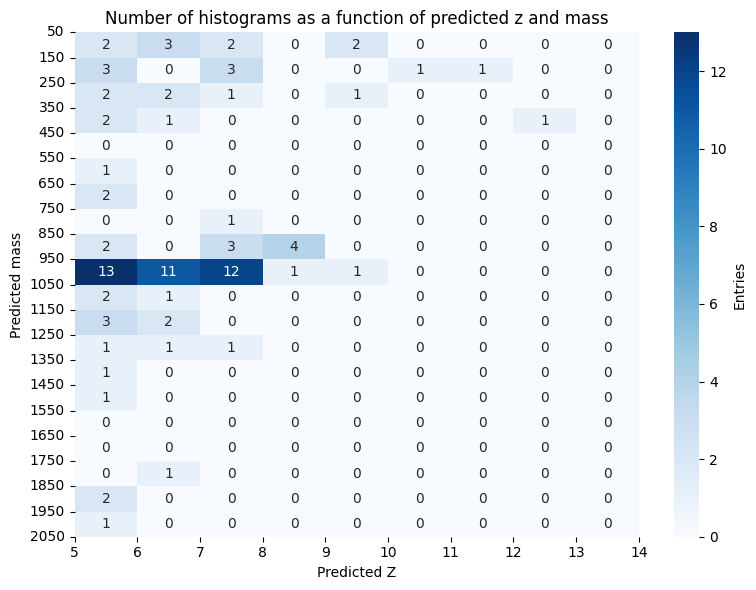

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/histograms_per_mass_per_z.png...


In [13]:
xdata = df[(df['zpred'] >= 5)]['zpred'].to_numpy()
ydata = df[(df['zpred'] >= 5)]['mpred'].to_numpy()

print('Z', np.min(xdata), np.max(xdata))
print('M', np.min(ydata), np.max(ydata))

x_binning = np.arange(5, 15, 1)
# x_binning = np.arange(5, 21, 15)
y_binning = np.arange(50, 2150, 100)

fig, ax = plt.subplots(figsize=(8, 6), dpi=100, layout='tight')
heatmap_data, x_binning, y_binning = np.histogram2d(xdata, ydata, bins=[x_binning, y_binning])
ax = heatmap(heatmap_data.T, annot=True, cmap='Blues', cbar_kws={'label': 'Entries'})
ax.set_title('Number of histograms as a function of predicted z and mass')
ax.set_xlabel('Predicted Z')
ax.set_ylabel('Predicted mass')
plt.xticks(np.arange(len(x_binning)), ['{}'.format(i) for i in x_binning], rotation='horizontal')
plt.yticks(np.arange(len(y_binning)), ['{}'.format(i) for i in y_binning], rotation='horizontal')
plt.show()

# Save the plot
output = f'{outdir}/histograms_per_mass_per_z.png'
print(f'Saving {output}...')
fig.savefig(output, dpi=300)
plt.close(fig)

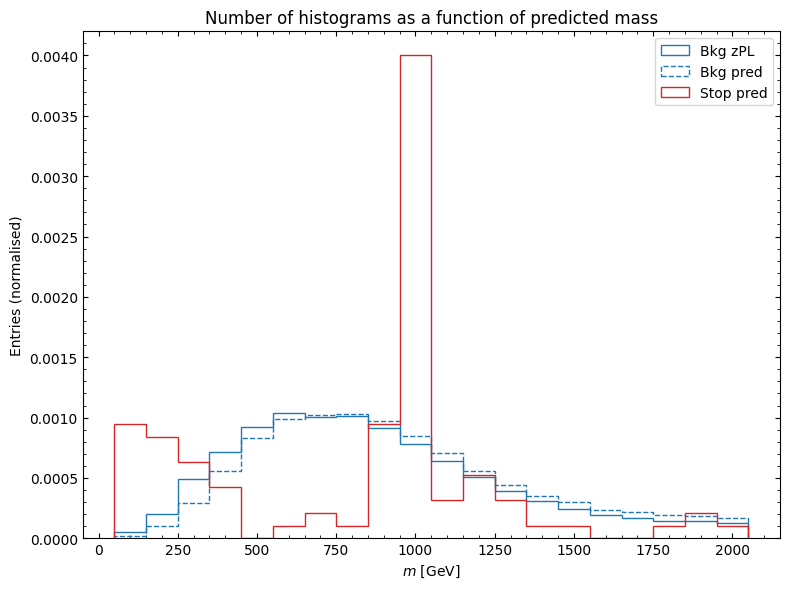

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/histograms_per_mass.png...


In [14]:
mdata = df[(df['zpred'] >= 5)]['mpred'].to_numpy()
mass_bkg = np.array([bkg.binning[i][np.argmax(row)] for i,row in enumerate(bkg.zpred)])
mass_bkg_true = np.array([bkg.binning[i][np.argmax(row)] for i,row in enumerate(bkg.ztrue)])

fig, ax = plt.subplots(figsize=(8, 6), dpi=100, layout='tight')
ydata, bin_edges, patches = ax.hist(mass_bkg_true, bins=y_binning, label='Bkg zPL', 
        histtype='step', density=True, color='tab:blue', linestyle='-')
ydata, bin_edges, patches = ax.hist(mass_bkg, bins=y_binning, label='Bkg pred', 
        histtype='step', density=True, color='tab:blue', linestyle='--')
ydata, bin_edges, patches = ax.hist(mdata, bins=y_binning, label='Stop pred',
        histtype='step', density=True, color='tab:red', linestyle='-')
# ax.annotate(f'[{bin_edges[np.argmax(ydata)]},{bin_edges[np.argmax(ydata)+1]}] GeV',
           # (0.5, 0.9), xycoords='axes fraction')
ax.legend()
ax.set_title('Number of histograms as a function of predicted mass')
ax.set_xlabel('$m$ [GeV]')
ax.set_ylabel('Entries (normalised)')

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=True)
ax.tick_params(axis='y', which='both', direction='in', left=True, right=True)
ax.tick_params(which='major', axis='both')
ax.tick_params(which='minor', axis='both')

plt.show()

# Save the plot
output = f'{outdir}/histograms_per_mass.png'
print(f'Saving {output}...')
fig.savefig(output, dpi=300)
plt.close(fig)

In [15]:
mass_lo, mass_hi = bin_edges[np.argmax(ydata)], bin_edges[np.argmax(ydata)+1]
print(mass_lo, mass_hi)

950.0 1050.0


In [16]:
# table1 = df[(df['zpred'] >= 5) & (df['mpred'] >= mass_lo) & (df['mpred'] <= mass_hi)]['category'].to_numpy()[:41]
# table2 = df[(df['zpred'] >= 5) & (df['mpred'] >= mass_lo) & (df['mpred'] <= mass_hi)]['category'].to_numpy()[41:]
# table = np.vstack([table1, table2]).T
table = df[(df['zpred'] >= 5) & (df['mpred'] >= mass_lo) & (df['mpred'] <= mass_hi)]['category'].to_numpy()
print(f'{table.shape[0]} histograms with z >= 5 and mass in [{mass_lo}, {mass_hi}] GeV')
df_table = pd.DataFrame(table, columns=['category'])
print(tabulate(df_table.to_numpy(), #headers=['',''],
               tablefmt='rounded_outline', floatfmt=".4g"))


38 histograms with z >= 5 and mass in [950.0, 1050.0] GeV
╭────────────────────────────────────────────────────────╮
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_4ex__mu0.j1_mass     │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_4ex__mu0.b0_mass     │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_5ex__mu0.j1_mass     │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_5ex__mu0.b0_mass     │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_6ex__mu0.j0_mass     │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_6ex__mu0.j1_mass     │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_6ex__mu0.b0_mass     │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_6ex__mu0.lj0_mass    │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_3ex__mu0.j1_mass    │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_5ex__mu0.j0_mass    │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_5ex__mu0.j1_mass    │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_6ex__mu0.j0_mass    │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_6ex__mu0.j1_mass    │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_2bExc_5ex__mu0.b0_mass     │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_1m_2bExc_6ex__mu0.b0_mass     

In [17]:
table = df[(df['zpred'] >= 5) & (df['zmax_bin'] <= 9)]['category'].to_numpy()
print(f'{table.shape[0]} histograms with z >= 5 with zmax in bin number <= 10')
df_table = pd.DataFrame(table, columns=['category'])
print(tabulate(df_table.to_numpy(), #headers=['',''],
               tablefmt='rounded_outline', floatfmt=".4g"))

19 histograms with z >= 5 with zmax in bin number <= 10
╭───────────────────────────────────────────────────────╮
│ hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_4ex__j2.j3_mass     │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_0m_1bExc_4ex__j0.j3_mass     │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_0m_incl_3ex__j0_massMET      │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_0m_incl_3ex__j2_massMET      │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_0m_incl_3ex__j1.j2_mass      │
│ hCat_0Wh_0T_0HM_0Z_0g_0e_0m_incl_4ex__j2.j3_mass      │
│ hCat_0Wh_1T_0HM_0Z_0g_0e_0m_0bExc_4ex__j2.j3_mass     │
│ hCat_0Wh_1T_0HM_0Z_0g_0e_0m_incl_4ex__j2.j3_mass      │
│ hCat_1Wh_0T_0HM_0Z_0g_0e_0m_0bExc_3ex__j1.j2_mass     │
│ hCat_1Wh_0T_0HM_0Z_0g_0e_0m_0bExc_4ex__j2.j3_mass     │
│ hCat_1Wh_0T_0HM_0Z_0g_0e_0m_1bExc_4ex__j2.j3_mass     │
│ hCat_1Wh_0T_0HM_0Z_0g_0e_0m_200Wh0pt_2ex__Wh0.j1_mass │
│ hCat_1Wh_0T_0HM_0Z_0g_0e_0m_200Wh0pt_3ex__j1.j2_mass  │
│ hCat_1Wh_0T_0HM_0Z_0g_0e_0m_200Wh0pt_4ex__j1.j3_mass  │
│ hCat_1Wh_0T_0HM_0Z_0g_0e_0m_200Wh0pt_4ex__j2.j3_mass  │
│ hCat_1Wh_0T_0H

## Plots

(38, 6)
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_4ex__mu0.j1_mass


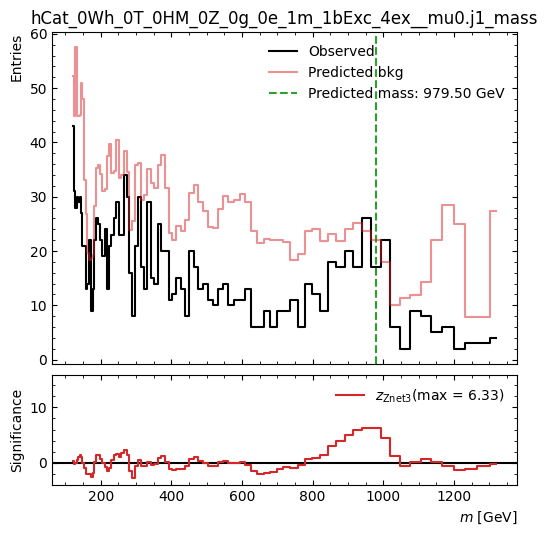

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_4ex__mu0.j1_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_4ex__mu0.b0_mass


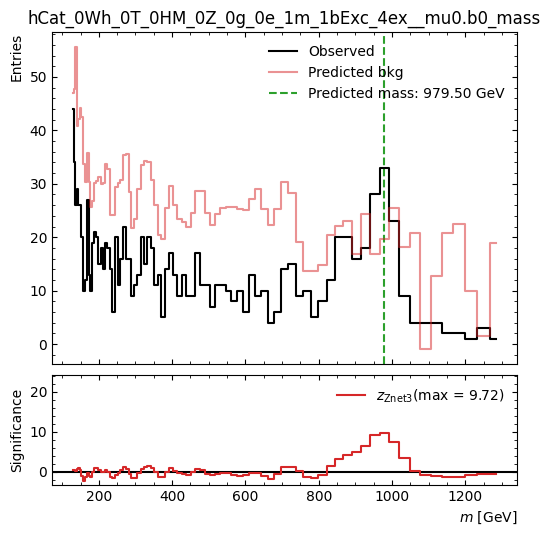

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_4ex__mu0.b0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_5ex__mu0.j1_mass


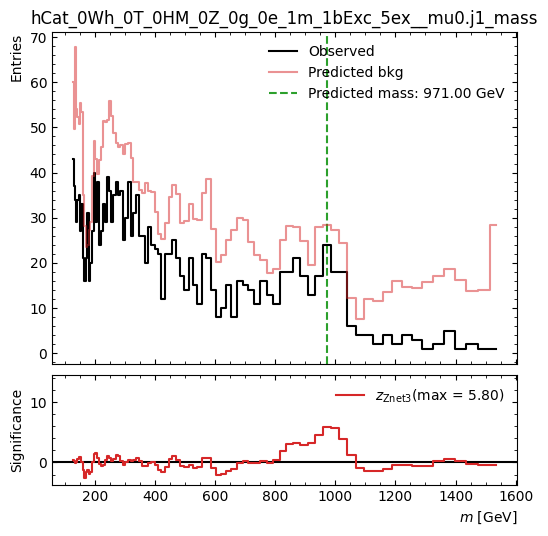

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_5ex__mu0.j1_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_5ex__mu0.b0_mass


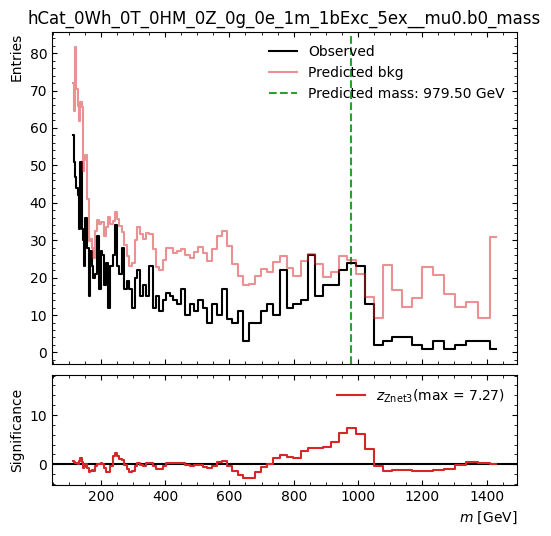

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_5ex__mu0.b0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_6ex__mu0.j0_mass


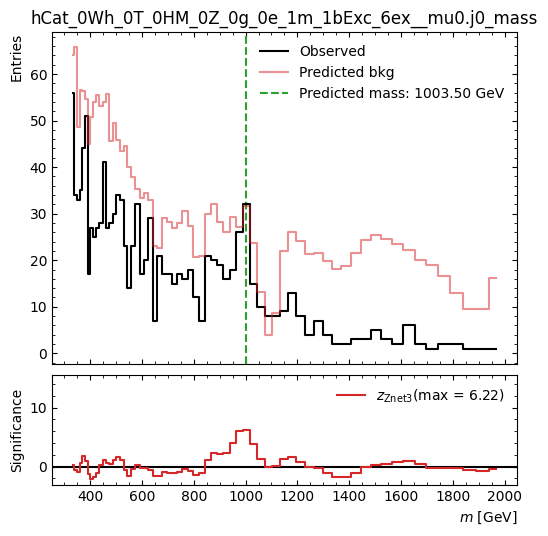

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_6ex__mu0.j0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_6ex__mu0.j1_mass


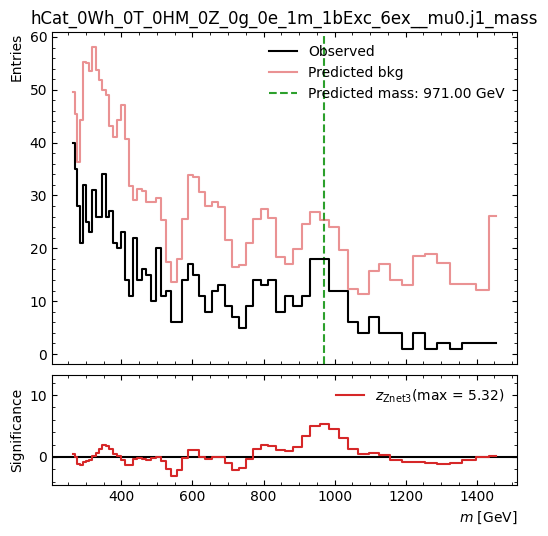

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_6ex__mu0.j1_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_6ex__mu0.b0_mass


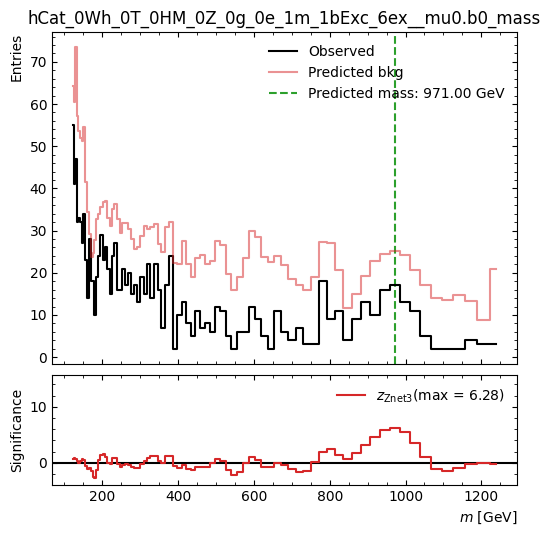

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_6ex__mu0.b0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_6ex__mu0.lj0_mass


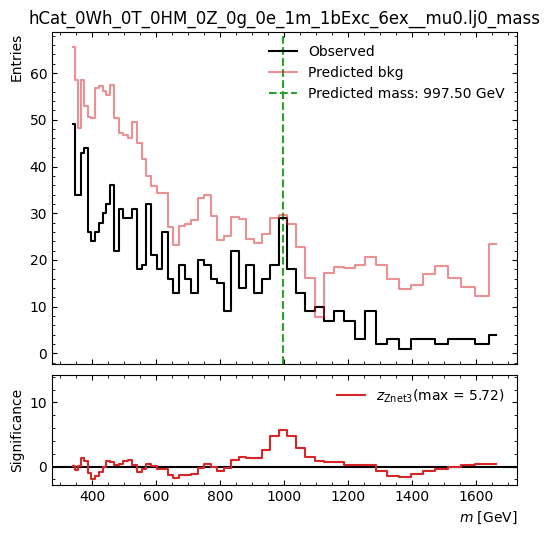

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_6ex__mu0.lj0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_3ex__mu0.j1_mass


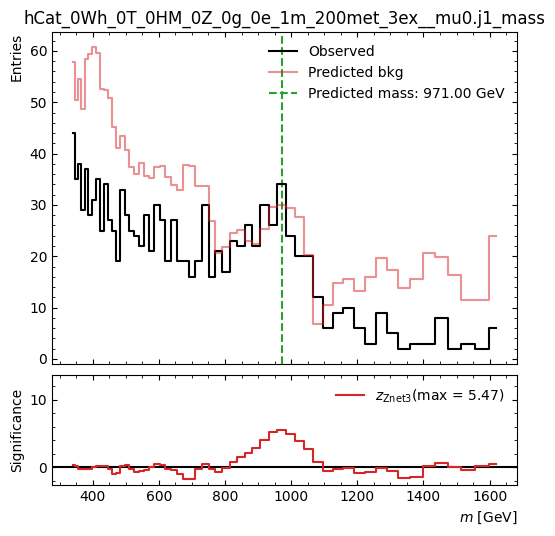

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_3ex__mu0.j1_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_5ex__mu0.j0_mass


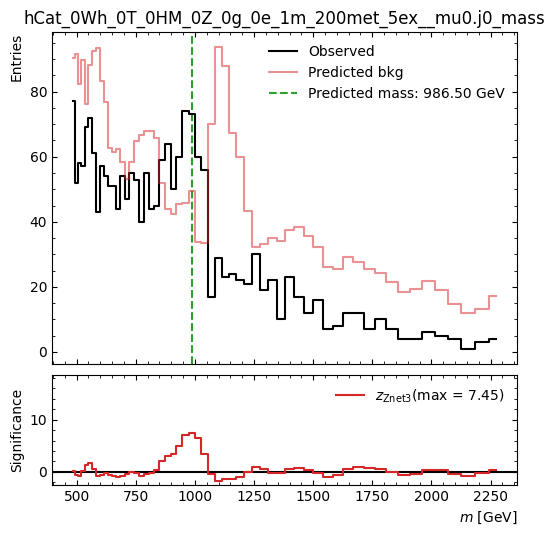

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_5ex__mu0.j0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_5ex__mu0.j1_mass


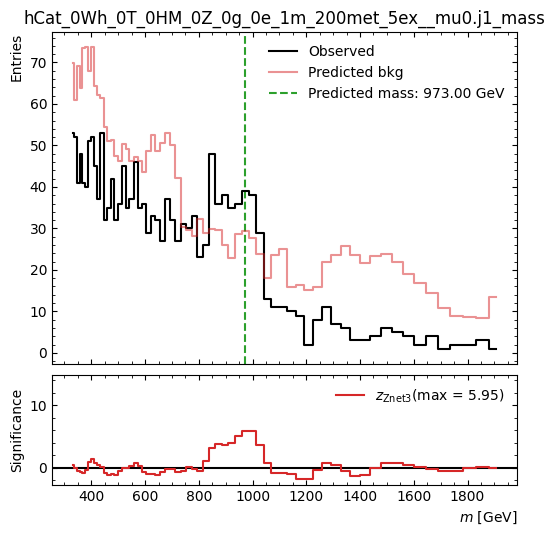

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_5ex__mu0.j1_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_6ex__mu0.j0_mass


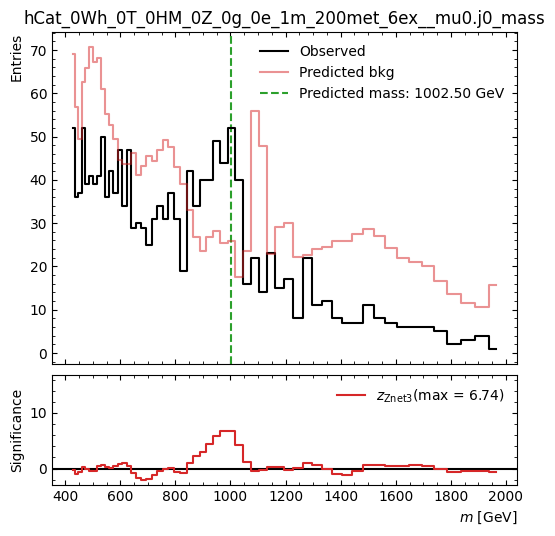

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_6ex__mu0.j0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_6ex__mu0.j1_mass


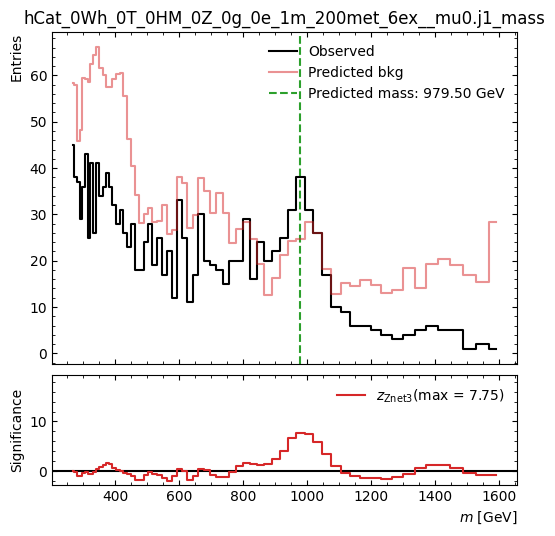

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_200met_6ex__mu0.j1_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_2bExc_5ex__mu0.b0_mass


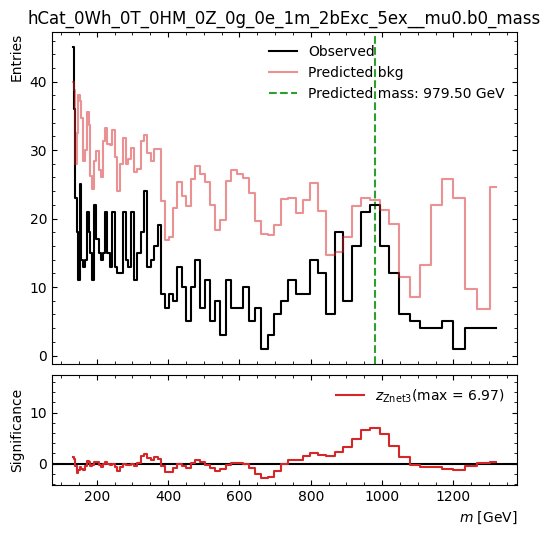

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_2bExc_5ex__mu0.b0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_2bExc_6ex__mu0.b0_mass


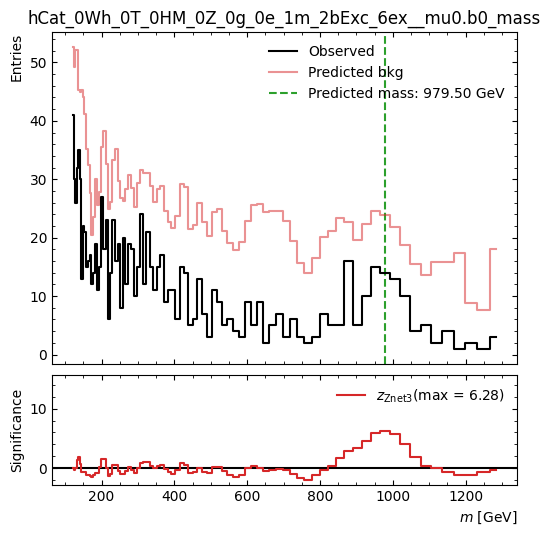

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_2bExc_6ex__mu0.b0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_3ex__mu0.j1_mass


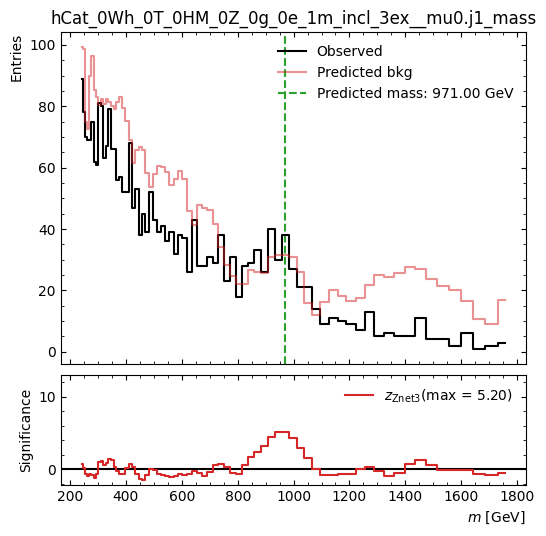

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_3ex__mu0.j1_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_4ex__mu0.j0_mass


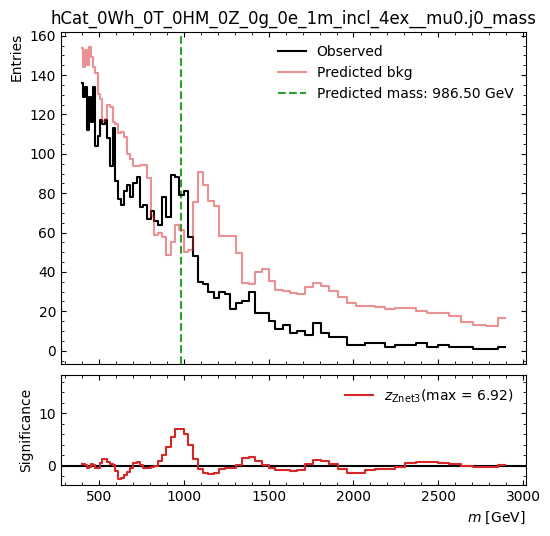

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_4ex__mu0.j0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_4ex__mu0.j1_mass


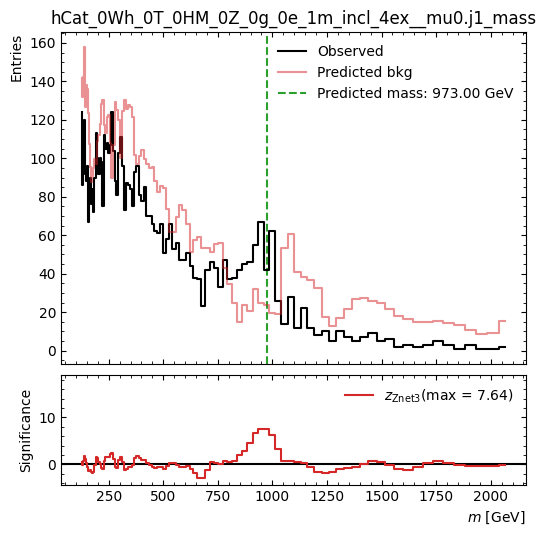

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_4ex__mu0.j1_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_5ex__mu0.j0_mass


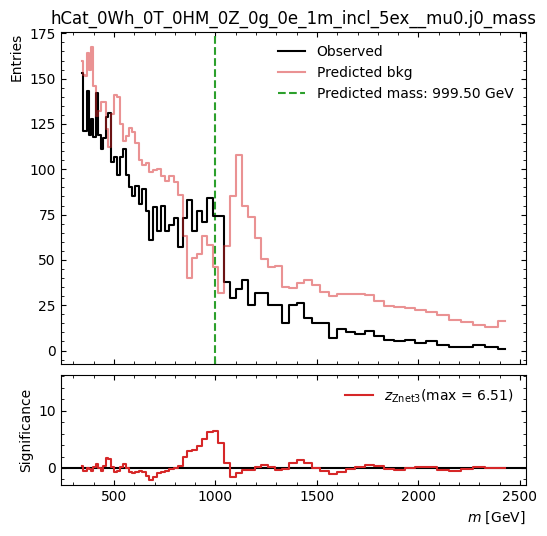

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_5ex__mu0.j0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_5ex__mu0.j1_mass


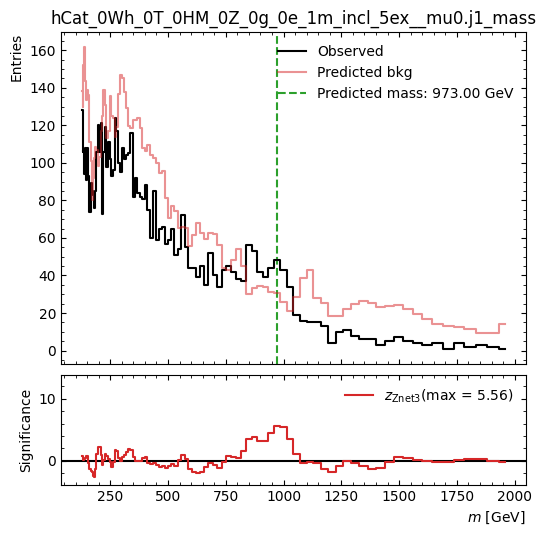

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_5ex__mu0.j1_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_6ex__mu0.j0_mass


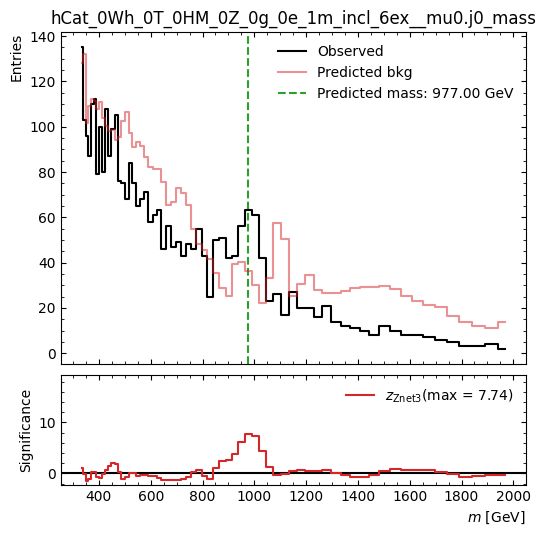

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_6ex__mu0.j0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_6ex__mu0.j1_mass


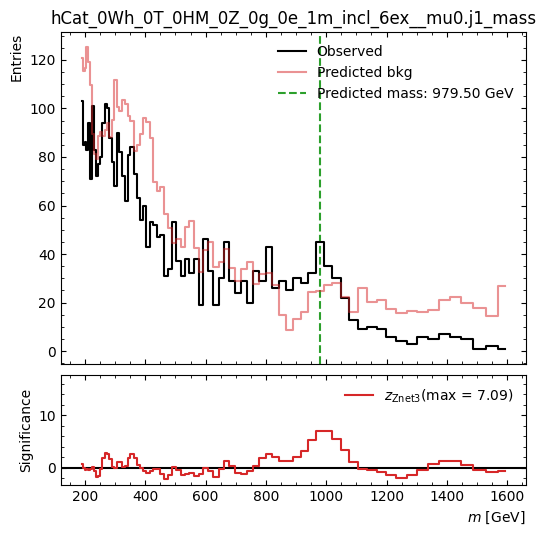

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_6ex__mu0.j1_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_7ex__mu0.j0_mass


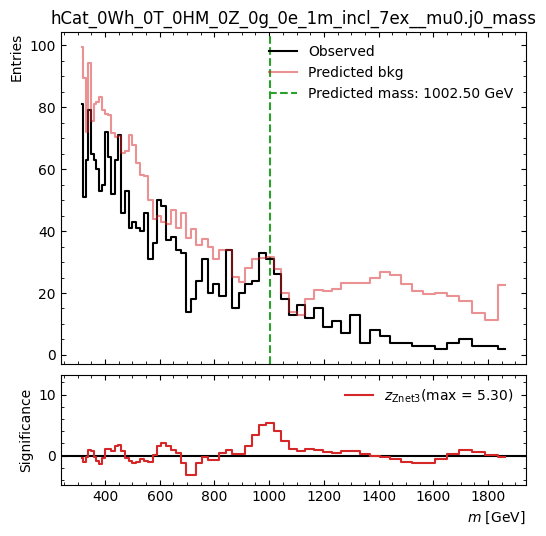

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_7ex__mu0.j0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_1e_0m_incl_4ex__el0.j0_mass


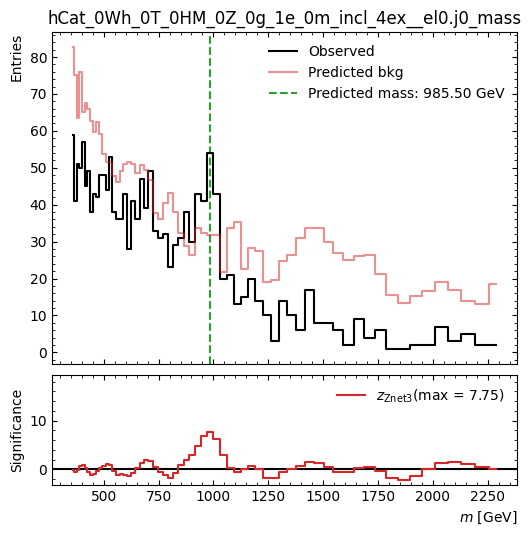

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_1e_0m_incl_4ex__el0.j0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_1e_0m_incl_4ex__el0.j1_mass


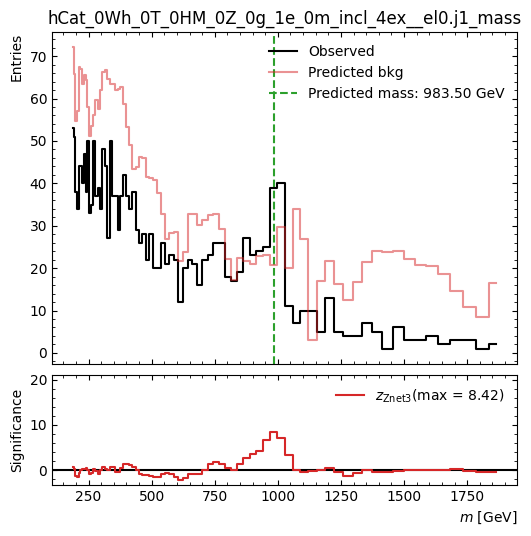

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_1e_0m_incl_4ex__el0.j1_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_1e_0m_incl_5ex__el0.j0_mass


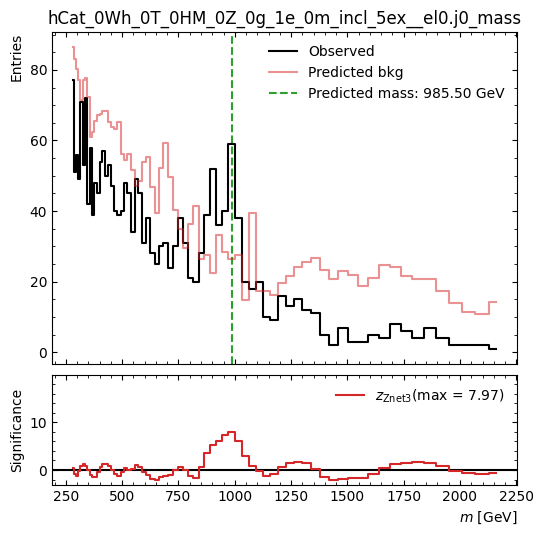

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_1e_0m_incl_5ex__el0.j0_mass.png...
hCat_0Wh_0T_0HM_0Z_0g_1e_0m_incl_6ex__el0.j0_mass


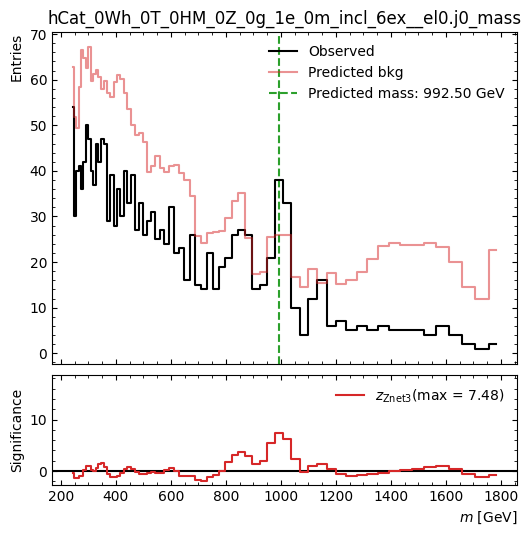

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_0Wh_0T_0HM_0Z_0g_1e_0m_incl_6ex__el0.j0_mass.png...
hCat_1Wh_0T_0HM_0Z_0g_0e_1m_0bExc_3ex__Wh0.mu0_mass


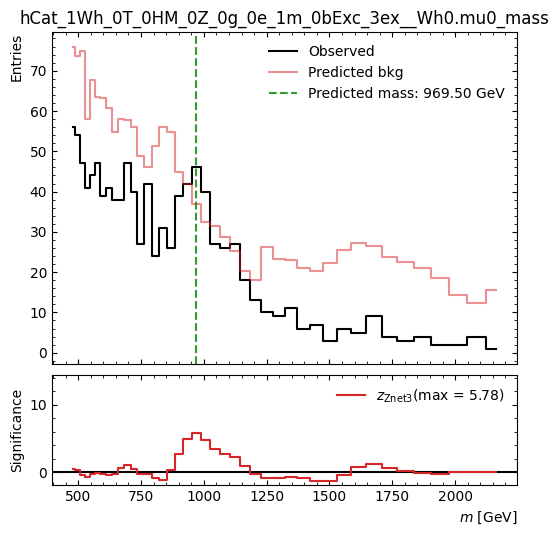

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_1Wh_0T_0HM_0Z_0g_0e_1m_0bExc_3ex__Wh0.mu0_mass.png...
hCat_1Wh_0T_0HM_0Z_0g_0e_1m_0bExc_4in__Wh0.mu0_mass


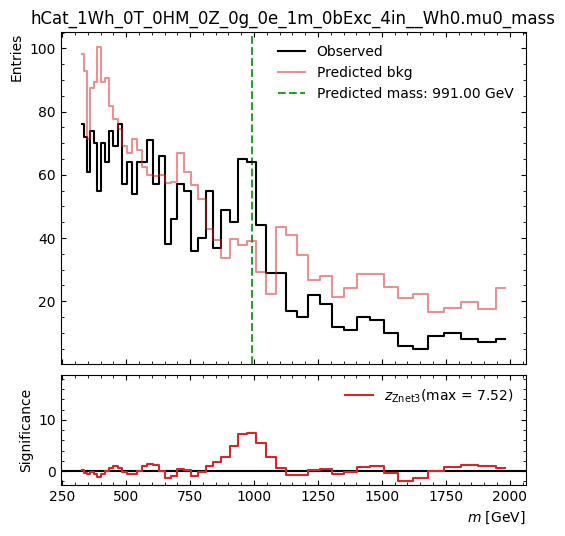

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_1Wh_0T_0HM_0Z_0g_0e_1m_0bExc_4in__Wh0.mu0_mass.png...
hCat_1Wh_0T_0HM_0Z_0g_0e_1m_200met_2ex__mu0.j0_mass


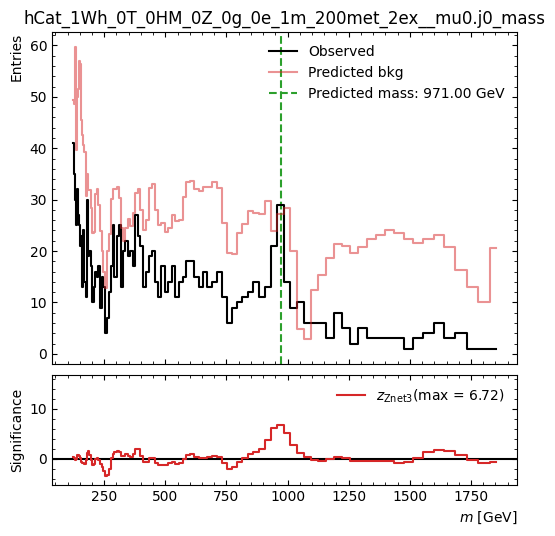

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_1Wh_0T_0HM_0Z_0g_0e_1m_200met_2ex__mu0.j0_mass.png...
hCat_1Wh_0T_0HM_0Z_0g_0e_1m_200met_3ex__mu0.j0_mass


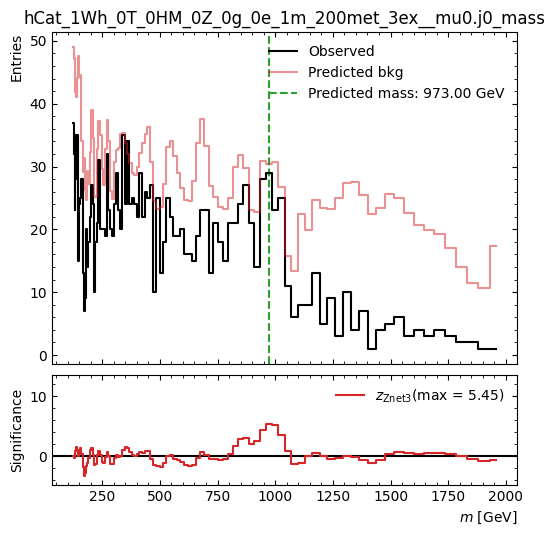

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_1Wh_0T_0HM_0Z_0g_0e_1m_200met_3ex__mu0.j0_mass.png...
hCat_1Wh_0T_0HM_0Z_0g_0e_1m_200Wh0pt_2ex__mu0.j0_mass


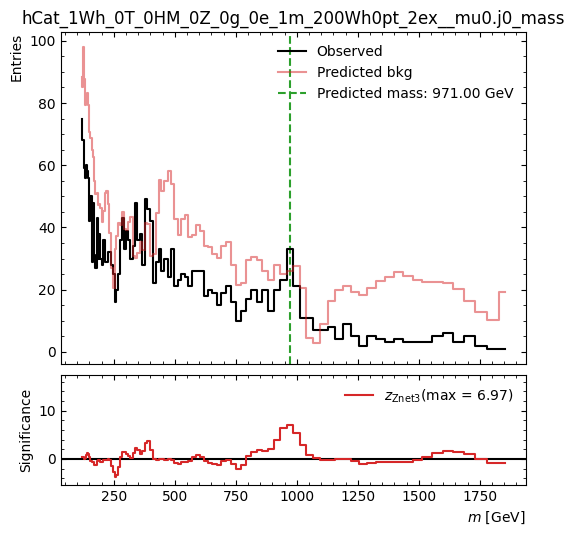

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_1Wh_0T_0HM_0Z_0g_0e_1m_200Wh0pt_2ex__mu0.j0_mass.png...
hCat_1Wh_0T_0HM_0Z_0g_0e_1m_200Wh0pt_3ex__mu0.j0_mass


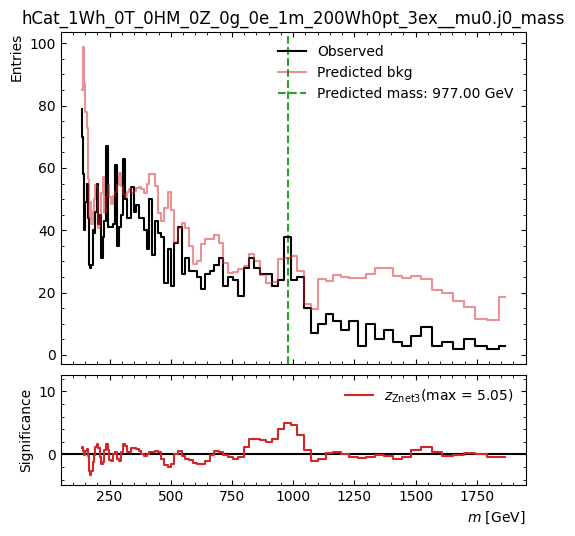

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_1Wh_0T_0HM_0Z_0g_0e_1m_200Wh0pt_3ex__mu0.j0_mass.png...
hCat_1Wh_0T_0HM_0Z_0g_0e_1m_200Wh0pt_4ex__Wh0.mu0_mass


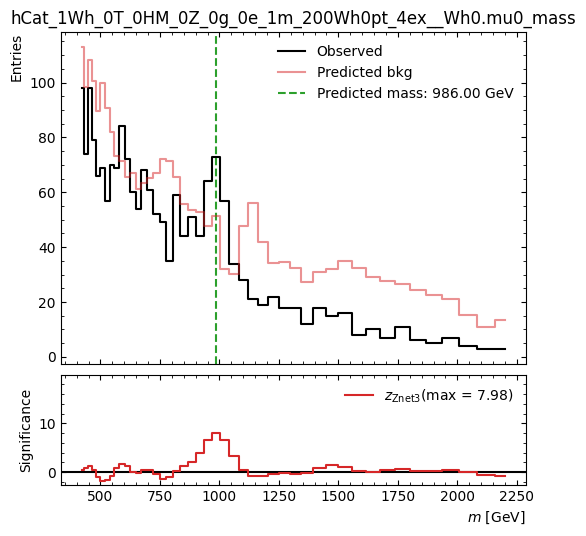

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_1Wh_0T_0HM_0Z_0g_0e_1m_200Wh0pt_4ex__Wh0.mu0_mass.png...
hCat_1Wh_0T_0HM_0Z_0g_0e_1m_incl_2ex__mu0.j0_mass


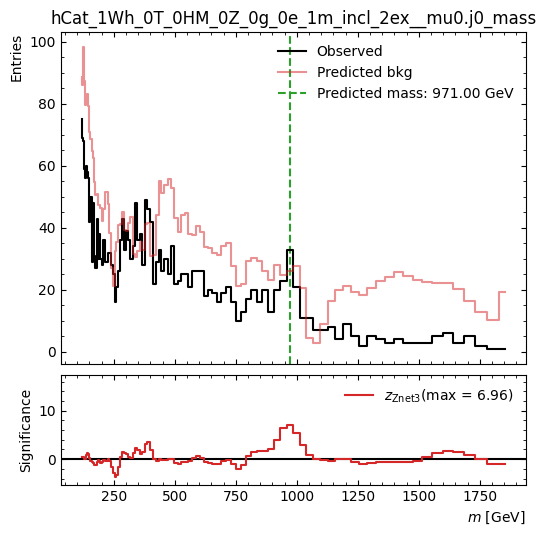

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_1Wh_0T_0HM_0Z_0g_0e_1m_incl_2ex__mu0.j0_mass.png...
hCat_1Wh_0T_0HM_0Z_0g_0e_1m_incl_4ex__Wh0.mu0_mass


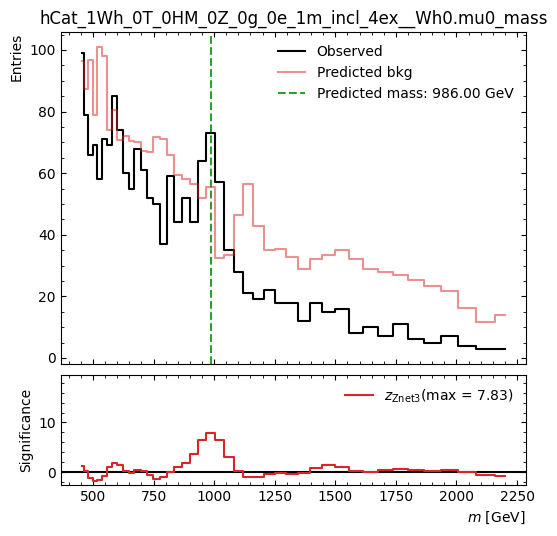

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_1Wh_0T_0HM_0Z_0g_0e_1m_incl_4ex__Wh0.mu0_mass.png...
hCat_1Wh_0T_0HM_0Z_0g_1e_0m_200Wh0pt_3ex__el0.j0_mass


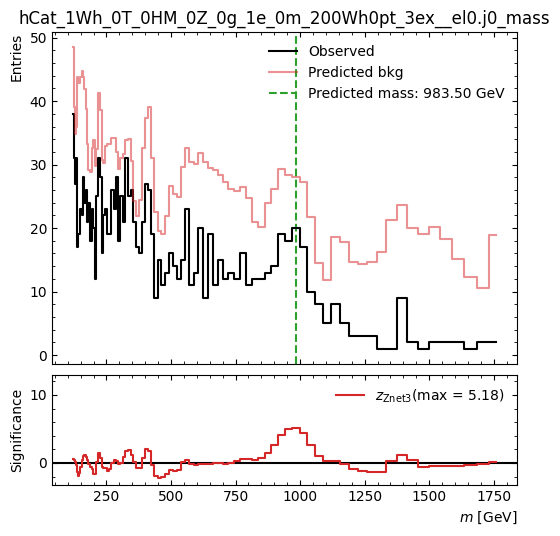

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_1Wh_0T_0HM_0Z_0g_1e_0m_200Wh0pt_3ex__el0.j0_mass.png...
hCat_1Wh_0T_0HM_0Z_0g_1e_0m_incl_3ex__el0.j0_mass


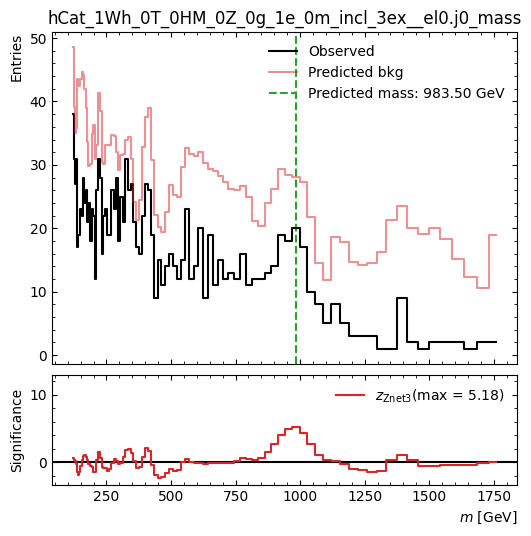

Saving ../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_st1000_chan3_nomassT/hists/hist_hCat_1Wh_0T_0HM_0Z_0g_1e_0m_incl_3ex__el0.j0_mass.png...


In [72]:
plots_N_max = 50
plotsdir = f"{config['output_dir']}/hists"
Path(plotsdir).mkdir(parents=True, exist_ok=True)

# Sub-selection of results
# _df = df[(df['zpred'] >= 5) & (df['zmax_bin'] <= 9)]
_df = df[(df['zpred'] >= 5) & (df['mpred'] >= mass_lo) & (df['mpred'] <= mass_hi)]

print(_df.shape)

N = 0 # Counter for plotted histograms
for row in _df.itertuples():
    if plots_N_max is not None and N > plots_N_max-1:
        break

    i = row.Index
    c = row.category
    print(c)
    
    idx = np.where(c == stop.cat)[0]
    if len(idx) > 1: 
        print('More than one histogram matching! Keeping just the first.')
    idx = idx[0]

    o = stop.obs[idx]
    bin_edges = stop.binning[idx]
    zp = stop.zpred[idx]
    bp = stop.bpred[idx] 
        
    # NOTE: to plot only histograms that satisfy a given condition, set
    # this condition here. By default we don't define any condition.
    condition = True
    # condition = np.max(zp) <= 70 and np.max(zp) >= 50
    # condition = np.max(zp) >= 50
    # condition = bin_edges[np.argmax(zp)] >= 990 and bin_edges[np.argmax(zp)] <= 1010 and np.max(zp) >= 5
    # pattern = re.compile('hCat_0Wh_0T_0HM_0Z_0g_0e_1m_1bExc_4ex')
    # pattern = re.compile('hCat_0Wh_0T_0HM_0Z_0g_0e_1m_incl_4ex')
    # condition = bool(pattern.search(c)) and np.max(zp) >= 5
    if not condition: continue
    N += 1

    bin_centers = (bin_edges[:-1]+bin_edges[1:])/2 if bin_edges is not None else np.arange(1, len(o)+1) + 0.5
    bin_widths = np.diff(bin_edges) if bin_edges is not None else np.ones(bin_centers.shape[0])
    title = f'{c}'#\n{get_readable_name(hname=c)}'
    
    # Plot
    nrows = 2
    gridspec_kw = {'height_ratios': [3] + [1]*(nrows-1), 'hspace': 0.05} if nrows != 1 else {}
    fig, ax = plt.subplots(nrows=nrows, ncols=1, figsize=(6,6), dpi=100,
                           sharex=True, gridspec_kw=gridspec_kw)
    if nrows == 1: ax = [ax]

    # ax[0].errorbar(bin_centers, o, label='Observed', # xerr=bin_widths/2,
    #                color='black', marker='o', markersize=3, linestyle='', zorder=100)
    ax[0].errorbar(bin_centers, o, label='Observed',
                   color='black', drawstyle='steps-mid')
#                    
    ax[0].errorbar(bin_centers, bp, label='Predicted bkg', color='tab:red', alpha=0.5,
                       drawstyle='steps-mid')
    ax[0].axvline(bin_centers[np.argmax(zp)], linestyle='--', color='tab:green', 
                  label=f'Predicted mass: {bin_centers[np.argmax(zp)]:.2f} GeV')

    ax[0].set_ylabel('Entries', loc='top')
    ax[0].set_title(title)
    log = False
    if log:
        ax[0].set_yscale('log')
    handles, labels = ax[0].get_legend_handles_labels()
    order = [1,2,0]
    ax[0].legend([handles[i] for i in order], [labels[i] for i in order],
                 loc='upper right', ncol=1, columnspacing=0.1, frameon=False)

    ax[1].errorbar(bin_centers, zp,
                   label=r'$z_{\mathrm{Znet3}}$' + f'(max = {np.nanmax(zp):.2f})',
                   color='tab:red', drawstyle='steps-mid')
    ax[1].set_xlabel('$m$ [GeV]', loc='right')
    ax[1].set_ylabel('Significance', loc='center')
    ax[1].axhline(color='black')
    ymin = 1.5*np.nanmin(zp) # supposes minimum is negative!
    ymax = 2.5*np.nanmax(zp)
    ax[1].set_ylim(ymin, ymax)
    ax[1].legend(loc='upper right', ncol=1, columnspacing=0.1, frameon=False)
       
    for k in range(nrows):
        # ax[k].legend(loc='upper right', ncol=[1,2,2][k], columnspacing=0.1, frameon=False)
        if not log or k != 0:
            ax[k].xaxis.set_minor_locator(AutoMinorLocator())
            ax[k].yaxis.set_minor_locator(AutoMinorLocator())
        ax[k].tick_params(axis='x', which='both', direction='in', bottom=True, top=True)
        ax[k].tick_params(axis='y', which='both', direction='in', left=True, right=True)
        ax[k].tick_params(which='major', axis='both')
        ax[k].tick_params(which='minor', axis='both')

    plt.show()

    # Save the plot
    output_path = f'{plotsdir}/hist_{c}.png' if c is not None else f'{outdir}/pred_hist_{i+1}.png'
    print(f'Saving {output_path}...')
    fig.subplots_adjust(hspace=0.0) # Removing the vertical gap between the subplots
    fig.savefig(output_path, bbox_inches='tight')
    plt.close(fig)

---